### Imports and Setup

In [1]:
import os

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import yaml
import numpy as np
import torch
from PIL import Image
import pandas as pd

from models.fusion_tcn import FusionTCN
from datasets.dataloaders import get_dataloaders
from utils.transformations import get_image_transform
from utils.transformations import to_spect

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# load config file
with open("config.yaml", 'r') as yaml_file:
    config = yaml.load(yaml_file, Loader=yaml.Loader)

Using the GPU!


Settings for evaluation

In [2]:
split = 'test'

### Prepare For Evaluation
Get dataloaders

In [4]:
dl = get_dataloaders(splits=['train', 'val', 'test'],
                    batch_size=128,
                    shuffle=False,
                    transform=get_image_transform(),
                    squeeze=True,
                    num_workers=20)

Load the desired model

In [5]:
model = FusionTCN(num_inputs=dl[split].dataset.num_TOSSITs,
                num_outputs=2,
                input_size=dl[split].dataset.size[0], 
                output_size=2,
                num_channels=[250, 800, 500] + 5*[368],
                kernel_size=6,
                dropout=0.05).to(device)

# load model weights
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'] + '/low_res', 'weights_best.pt'),
                        map_location=device)['model_state_dict']
model.load_state_dict(state_dict)

<All keys matched successfully>

### Evaluate Model On Synthetic Data
Get predictions and labels

In [6]:
def evaluate_model(model, dataloader):
    """
    Get lists of targets and predictions using a provided model and dataloader.
    
    Parameters
    ----------
    model : nn.Module
        model to be evaluated
    dataloader : data.DataLoader
        dataloader to use in model evaluation
    
    Returns
    -------
    x_p : array-like
        list of predicted X components
    x_t : array-like
        list of true X components
    y_p : array-like
        list of predicted Y components
    y_t : array-like
        list of true Y components
    outputs_all : array-like
        all model outputs
    """
    # put model in evaluatio mode
    model.eval()
    
    # get target scaling values
    max_x = dataloader.dataset.max_x
    max_y = dataloader.dataset.max_y
    
    # initialize arrays for results
    x_t, x_p, y_t, y_p, outputs_all = [], [], [], [], []
    
    for inputs, x_targets, y_targets in tqdm(dataloader):
        
        # put data on device
        inputs = inputs.to(device)
        x_targets = x_targets.to(device)
        y_targets = y_targets.to(device)
        
        with torch.set_grad_enabled(False):
            # get outputs and store
            outputs = model(inputs)
            
            outputs_all += outputs.detach().tolist()
            
            # store x predictions and labels
            x_p += (outputs[:,[0]] * max_x).detach().tolist()
            x_t += (x_targets * max_x).detach().tolist()
            
            # store y predictions and labels
            y_p += (outputs[:,[1]] * max_y).detach().tolist()
            y_t += (y_targets * max_y).detach().tolist()
    
    return np.asarray(x_p), np.asarray(x_t), np.asarray(y_p), np.asarray(y_t), np.asarray(outputs_all)

In [7]:
x_p, x_t, y_p, y_t, outputs_all = evaluate_model(model, dl[split])

  0%|          | 0/21 [00:00<?, ?it/s]

Plot predicteda and true X/Y componenets and rought predicted and true range

In [12]:
def plot_regressions(x_t, x_p, y_t, y_p, dataloader=None, valid=True):
    """
    Plot regression results.
    
    Parameters
    ----------
    x_p : array-like
        list of predicted X components
    x_t : array-like
        list of true X components
    y_p : array-like
        list of predicted Y components
    y_t : array-like
        list of true Y components
    dataloader : torch.utils.data.DataLoader
        dataloader used to produce x_t, x_p, y_t, y_p
    valid : bool
        whether or not to use only valid examples (source at a true bathymetry location)
    """

    if valid:
        # make sure we have a dataloader
        assert dataloader is not None, "dataloader needed to produce valid examples"
        
        # get data, labels, and indices of split
        dataset = dataloader.dataset.inputs['data']
        labels = dataloader.dataset.inputs['labels'][:]
        idx = dataloader.batch_sampler.idx
        valid_labels = labels[idx,5].astype(int)
        x_t = x_t[valid_labels==1,:]
        x_p = x_p[valid_labels==1,:]
        y_t = y_t[valid_labels==1,:]
        y_p = y_p[valid_labels==1,:]
    
    # convert to km
    x_t = x_t / 1000
    x_p = x_p / 1000
    y_t = y_t / 1000
    y_p = y_p / 1000
    
    # rough range error (assuming flat Earth)
    r_t = np.sqrt(x_t ** 2 + y_t ** 2)
    r_p = np.sqrt(x_p ** 2 + y_t ** 2)
    
    distances = np.sqrt((x_t - x_p) ** 2 + (y_t - y_p) ** 2)
    
    # get endpoints for identity lines
    x_mm = (np.min(x_t), np.max(x_t))
    y_mm = (np.min(y_t), np.max(y_t))
    r_mm = (np.min(r_t), np.max(r_t))
    
    f, (ax1, ax2, ax3) = plt.subplots(1, 3)
    f.set_figheight(4)
    f.set_figwidth(15)
    
    # X component
    ax1.plot(x_t, x_p, 'bo', markersize=2, label="predictions")
    ax1.plot([x_mm[0], x_mm[1]], [x_mm[0], x_mm[1]], 'r--', label="identity line")
    ax1.legend()
    ax1.grid()
    ax1.set_xlabel("True X Component [km]")
    ax1.set_ylabel("Predicted Distance [km]")
    
    # Y component
    ax2.plot(y_t, y_p, 'bo', markersize=2, label="predictions")
    ax2.plot([y_mm[0], y_mm[1]], [y_mm[0], y_mm[1]], 'r--', label="identity line")
    ax2.legend()
    ax2.grid()
    ax2.set_xlabel("True Y Component [km]")
    
    # rough range
    ax3.plot(r_t, r_p, 'bo', markersize=2, label="predictions")
    ax3.plot([r_mm[0], r_mm[1]], [r_mm[0], r_mm[1]], 'r--', label="identity line")
    ax3.legend()
    ax3.grid()
    ax3.set_xlabel("True Rough Range [km]")
    
    plt.figure()
    plt.grid(zorder=3)
    plt.hist(distances, bins='auto', edgecolor='black', zorder=4)
    plt.xlabel("Distance Between Predicted and Ground Truth Location [km]")
    plt.ylabel("Number of Examples")
    
    # calculate component errors
    MSE_X = ((x_t - x_p) ** 2).mean()
    MSE_Y = ((y_t - y_p) ** 2).mean()
    MSE_R = ((r_t - r_p) ** 2).mean()
    
    print("statistics")
    print("-------------------")
    print("MSE (X): {:.3f} km^2".format(MSE_X))
    print("RMSE (X): {:.3f} km".format(np.sqrt(MSE_X)))
    print("-------------------")
    print("MSE (Y): {:.3f} km^2".format(MSE_Y))
    print("RMSE (Y): {:.3f} km".format(np.sqrt(MSE_Y)))
    print("-------------------")
    print("MSE (R): {:.3f} km^2".format(MSE_R))
    print("RMSE (R): {:.3f} km".format(np.sqrt(MSE_R)))
    print("-------------------")

statistics
-------------------
MSE (X): 1.802 km^2
RMSE (X): 1.342 km
-------------------
MSE (Y): 0.574 km^2
RMSE (Y): 0.758 km
-------------------
MSE (R): 0.175 km^2
RMSE (R): 0.418 km
-------------------


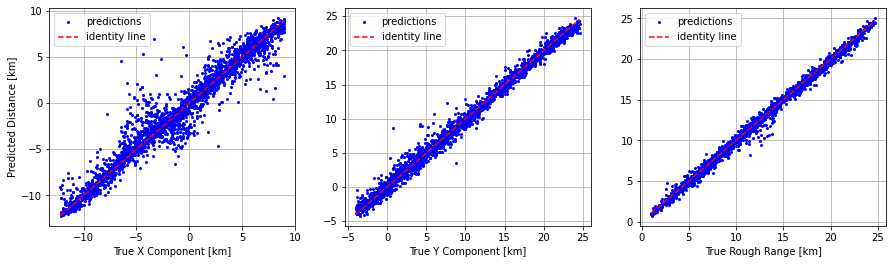

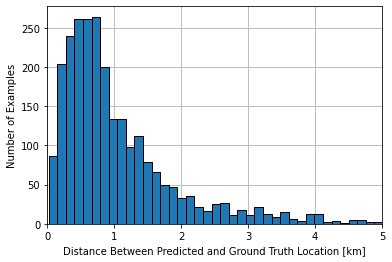

In [13]:
plot_regressions(x_t, x_p, y_t, y_p, dl[split], valid=True)

### Display High Error Calls

In [17]:
def plot_top_k_error(x_t, x_p, y_t, y_p, dataloader, k=5, highest=True, valid=True):
    """
    Plot top/bottom-k error calls.
    
    Parameters
    ----------
    x_p : array-like
        list of predicted X components
    x_t : array-like
        list of true X components
    y_p : array-like
        list of predicted Y components
    y_t : array-like
        list of true Y components
    dataloader : torch.utils.data.DataLoader
        dataloader used to produce x_t, x_p, y_t, y_p
    k : int
        number of top/bottom error calls to plot
    highest : bool
        whether to plot the highest/lowest error calls
    valid : bool
        whether or not to use only valid examples (source at a true bathymetry location)
    """
    # get data, labels, and indices of split
    dataset = dataloader.dataset.inputs['data']
    labels = dataloader.dataset.inputs['labels'][:]
    idx = dataloader.batch_sampler.idx
    
    # get valid examples only
    if valid:
        valid_labels = labels[idx,5].astype(int)
        x_t = x_t[valid_labels == 1,:]
        x_p = x_p[valid_labels == 1,:]
        y_t = y_t[valid_labels == 1,:]
        y_p = y_p[valid_labels == 1,:]
        idx = idx[valid_labels == 1]
    
    # sum X/Y absolute errors and get indices from largest to smallest
    top_k_abs_err = np.sqrt((x_t - x_p) ** 2 + (y_t - y_p) ** 2)
    inds = top_k_abs_err.squeeze().argsort()[::-1][:k] if highest else top_k_abs_err.squeeze().argsort()[:k]
    
    # get number of sensors per call
    num_TOSSITs = dataset.shape[1]
    
    # initialize dataframe
    df = pd.DataFrame(columns=["GT-P Distance [m]", 
                               "Y-Component GT [m]",
                               "Y-Component P [m]",
                               "Y-Component Abs. Error [m]",
                               "X-Component GT [m]",  
                               "X-Component P [m]",
                               "X-Component Abs. Error [m]"])
    
    x_list, y_list = [], []
    for d in range(k):
        # store coordinates
        top_k_X = dataset[idx[inds[d]],...]
        x_list.append(labels[idx[inds[d]],1])
        y_list.append(labels[idx[inds[d]],0])
        
        # append row to dataframe
        df_row = pd.DataFrame({"GT-P Distance [m]": [np.around(top_k_abs_err[inds[d]][0], 2)],
                               "Y-Component GT [m]": [np.around(y_t[inds[d]].squeeze(), 2)],
                               "Y-Component P [m]": [np.around(y_p[inds[d]].squeeze(), 2)],
                               "Y-Component Abs. Error [m]": [np.around(np.abs(y_t[inds[d]].squeeze() - y_p[inds[d]].squeeze()), 2)],
                               "X-Component GT [m]": [np.around(x_t[inds[d]].squeeze(), 2)],
                               "X-Component P [m]": [np.around(x_p[inds[d]].squeeze(), 2)],
                               "X-Component Abs. Error [m]": [np.around(np.abs(x_t[inds[d]].squeeze() - x_p[inds[d]].squeeze()), 2)]})
        df = pd.concat([df, df_row], ignore_index=True)
        
        # only plot signals if fewer than 20 calls
        if k < 20:
            plt.figure()
            for t in range(num_TOSSITs):
                spect = to_spect(top_k_X[t])
                plt.subplot(1,num_TOSSITs, t+1)
                plt.imshow(spect.squeeze())
                plt.title(f"TOSSIT {t+1}")
                plt.axis('off')
            plt.tight_layout()
    
    # show dataframe tail if less than 20 signals
    if k < 20:
        display(df)
    else:
        display(df.head())
    
    # overlay points onto map
    plt.figure()
    img = Image.open(config['dataset']['data_directory'] + '/map.tif', mode='r', formats=None)
    plt.scatter(x_list, y_list, c='#0307fc', s=2, label='ground truth')
    ylmax, ylmin = plt.gca().get_ylim()
    xlmin, xlmax = plt.gca().get_xlim()
    plt.gca().invert_yaxis()
    implot = plt.imshow(img, extent=(config['scaling']['min_x'], config['scaling']['max_x'], config['scaling']['max_y'], config['scaling']['min_y']))
    plt.legend()
    plt.xlabel("X Component [m]")
    plt.ylabel("Y Component [m]")

,GT-P Distance [m],Y-Component GT [m],Y-Component P [m],Y-Component Abs. Error [m],X-Component GT [m],X-Component P [m],X-Component Abs. Error [m]
0,4651.69,6486.35,9865.16,3378.81,13026.21,9829.05,3197.17
1,4137.98,21404.96,23177.62,1772.67,12777.32,9038.26,3739.06
2,3443.95,10470.82,13781.77,3310.95,-4344.51,-3396.67,947.84
3,2469.01,22331.58,20664.91,1666.67,10015.96,8194.36,1821.60
4,2445.79,8895.57,6502.82,2392.74,-5170.89,-5677.49,506.60


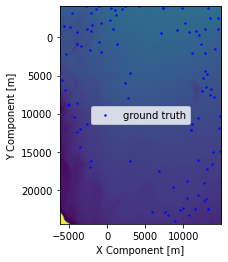

In [19]:
plot_top_k_error(x_t, 
                 x_p, 
                 y_t, 
                 y_p, 
                 dl[split],
                 highest=True,
                 k=100,
                 valid=True)